# Amazon Alexa Reviews — Sentiment Analysis


In [4]:
import pandas as pd                          
import numpy as np                           
import re                                    
import matplotlib.pyplot as plt              
import seaborn as sns                        
from wordcloud import WordCloud              

# These are the machine learning tools we need
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 — Load the Dataset

In [5]:
df = pd.read_csv('amazon_alexa.tsv', sep='\t')
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


## Step 3 — Explore the Data (EDA)

The column we want to predict is **`feedback`**:
- `1` = Positive review
- `0` = Negative review

In [9]:
# How many positive vs negative reviews are there?
print(df['feedback'].value_counts())
print()
print("Positive:", (df['feedback'] == 1).sum())
print("Negative:", (df['feedback'] == 0).sum())

feedback
1    2893
0     257
Name: count, dtype: int64

Positive: 2893
Negative: 257


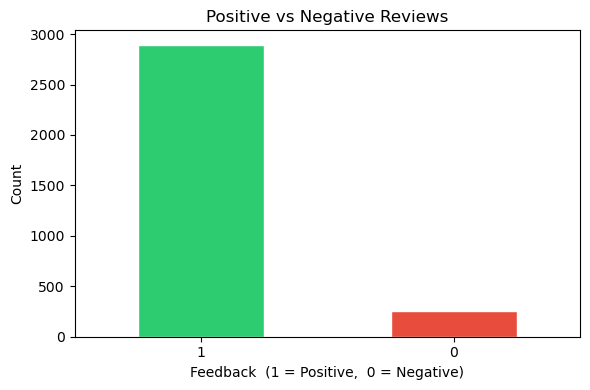

In [10]:
# Plot the feedback distribution
plt.figure(figsize=(6, 4))
df['feedback'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('Positive vs Negative Reviews')
plt.xlabel('Feedback  (1 = Positive,  0 = Negative)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

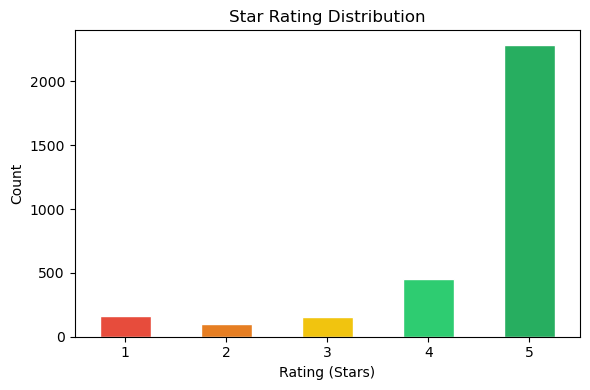

In [11]:
# Plot the star rating distribution
plt.figure(figsize=(6, 4))
df['rating'].value_counts().sort_index().plot(kind='bar',
    color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], edgecolor='white')
plt.title('Star Rating Distribution')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Look at some example reviews
print("--- Example POSITIVE reviews ---")
for review in df[df['feedback'] == 1]['verified_reviews'].dropna().head(3):
    print("-", review)

print()
print("--- Example NEGATIVE reviews ---")
for review in df[df['feedback'] == 0]['verified_reviews'].dropna().head(3):
    print("-", review)

--- Example POSITIVE reviews ---
- Love my Echo!
- Loved it!
- Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.

--- Example NEGATIVE reviews ---
- It's like Siri, in fact, Siri answers more accurately then Alexa.  I don't see a real need for it in my household, though it was a good bargain on prime day deals.
- Sound is terrible if u want good music too get a bose
- Not much features.


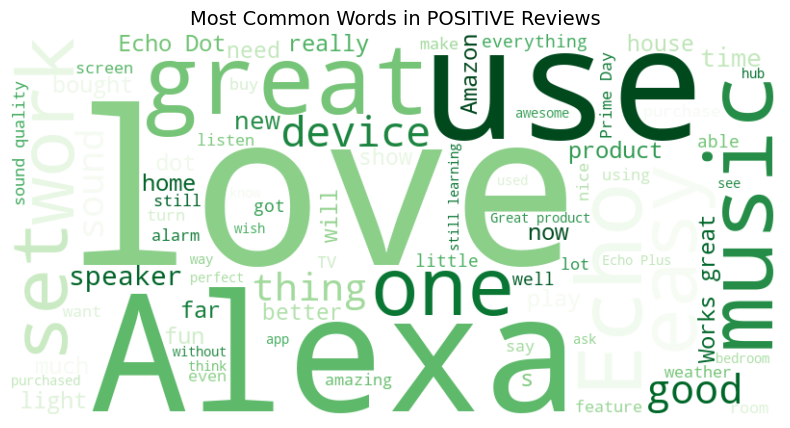

In [13]:
# Word Cloud for POSITIVE reviews
positive_text = ' '.join(df[df['feedback'] == 1]['verified_reviews'].dropna())

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Greens', max_words=80).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in POSITIVE Reviews', fontsize=14)
plt.show()

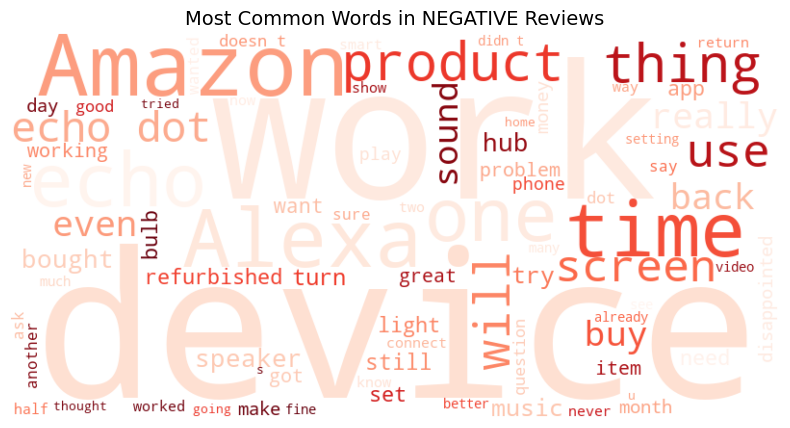

In [14]:
# Word Cloud for NEGATIVE reviews
negative_text = ' '.join(df[df['feedback'] == 0]['verified_reviews'].dropna())

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=80).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in NEGATIVE Reviews', fontsize=14)
plt.show()

## Step 4 — Clean the Text

We need to clean the reviews before feeding them to the model.
This means: removing punctuation, making everything lowercase, etc.

In [15]:
def clean_text(text):
    # If the value is not a string (e.g. NaN), return empty string
    if not isinstance(text, str):
        return ''
    # Make everything lowercase
    text = text.lower()
    # Remove punctuation and numbers, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = text.strip()
    return text

# Apply the function to every review
df['clean_review'] = df['verified_reviews'].apply(clean_text)

# See before and after
print("BEFORE:", df['verified_reviews'].iloc[3])
print()
print("AFTER: ", df['clean_review'].iloc[3])

BEFORE: I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like categories. Has nice sound when playing music as well.

AFTER:  i have had a lot of fun with this thing my  yr old learns about dinosaurs i control the lights and play games like categories has nice sound when playing music as well


In [16]:
# Remove any rows where the review is now empty
df = df[df['clean_review'].str.len() > 0]
df = df.reset_index(drop=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 3065


## Step 5 — Prepare Data for the Model

Machine learning models can't read words — they need numbers.

We use **TF-IDF** to convert each review into a row of numbers.  
TF-IDF stands for *Term Frequency – Inverse Document Frequency*.  
It gives higher scores to words that are important in a review but rare across all reviews.

In [18]:
# X = the reviews (input), y = feedback label (what we want to predict)
X = df['clean_review']
y = df['feedback']

# Split into training set (80%) and test set (20%)
# The model learns from the training set and is tested on the test set
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42,stratify=y)

print("Training reviews:", len(X_train))
print("Testing reviews: ", len(X_test))

Training reviews: 2452
Testing reviews:  613


In [19]:
# Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)   # use only the top 5000 words

# Fit on training data and transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Shape of training matrix:", X_train_tfidf.shape)
# (rows = reviews, columns = words)

Shape of training matrix: (2452, 3963)


## Step 6 — Train the Model

We use **Logistic Regression** — a simple and effective model for text classification.

In [20]:
# Create the model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train it on the training data
model.fit(X_train_tfidf, y_train)

print("Model trained!")

Model trained!


In [21]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 94.78%


## Step 7 — Evaluate the Results

In [22]:
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.62      0.81      0.70        47
    Positive       0.98      0.96      0.97       566

    accuracy                           0.95       613
   macro avg       0.80      0.88      0.84       613
weighted avg       0.96      0.95      0.95       613



<Figure size 500x400 with 0 Axes>

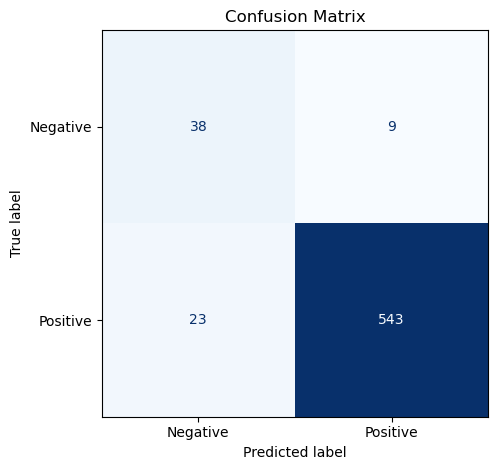

In [23]:
# Confusion Matrix
# Shows how many reviews were correctly/incorrectly classified

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

plt.figure(figsize=(5, 4))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

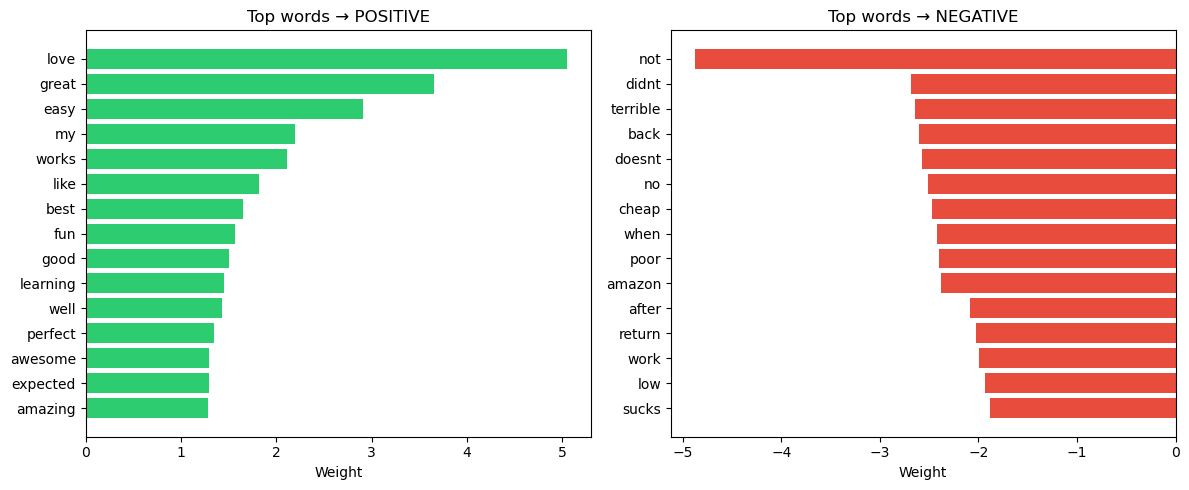

In [24]:
# Which words push the prediction toward POSITIVE or NEGATIVE?

feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

top_positive_idx = coefs.argsort()[-15:][::-1]
top_negative_idx = coefs.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Positive words
axes[0].barh([feature_names[i] for i in top_positive_idx][::-1],
             [coefs[i] for i in top_positive_idx][::-1], color='#2ecc71')
axes[0].set_title('Top words → POSITIVE', fontsize=12)
axes[0].set_xlabel('Weight')

# Negative words
axes[1].barh([feature_names[i] for i in top_negative_idx][::-1],
             [coefs[i] for i in top_negative_idx][::-1], color='#e74c3c')
axes[1].set_title('Top words → NEGATIVE', fontsize=12)
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()

---
## Step 8 — Predict on Your Own Reviews!

Now the fun part — type any review and see what the model thinks.

In [25]:
def predict_review(review_text):
    # Clean the text the same way we cleaned our training data
    cleaned = clean_text(review_text)
    # Convert to TF-IDF numbers
    features = tfidf.transform([cleaned])
    # Make prediction
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]

    label = "POSITIVE" if prediction == 1 else "NEGATIVE"
    confidence = probability[prediction] * 100

    print(f"Review:     '{review_text}'")
    print(f"Prediction: {label}  ({confidence:.1f}% confident)")
    print()

In [26]:
# Try some example reviews!
predict_review("I absolutely love this product, it works great!")
predict_review("Terrible, stopped working after one week.")
predict_review("It is okay, nothing special but gets the job done.")
predict_review("Best thing I ever bought, highly recommend to everyone!")
predict_review("Waste of money, very disappointed with this purchase.")

Review:     'I absolutely love this product, it works great!'
Prediction: POSITIVE  (98.2% confident)

Review:     'Terrible, stopped working after one week.'
Prediction: NEGATIVE  (92.1% confident)

Review:     'It is okay, nothing special but gets the job done.'
Prediction: POSITIVE  (59.5% confident)

Review:     'Best thing I ever bought, highly recommend to everyone!'
Prediction: POSITIVE  (81.0% confident)

Review:     'Waste of money, very disappointed with this purchase.'
Prediction: NEGATIVE  (65.3% confident)



In [32]:
my_review = "Siri is better"
predict_review(my_review)

Review:     'Siri is better'
Prediction: NEGATIVE  (59.7% confident)

